# USA Real Estate Data Quality Audit — Part 2: Validating detectors against planted errors

**Author:** Mariam Fathi · **Data:** USA Real Estate Dataset (2,226,382 listings) · **Code:** `src/reaudit`, `experiments/run_validation.py`

**Series:** [Part 1: Root-cause analysis](https://www.kaggle.com/code/mariamfathiamin/real-estate-audit-1-root-cause-analysis) · **Part 2: Validating detectors** · [Part 3: Duplicate leakage](https://www.kaggle.com/code/mariamfathiamin/real-estate-audit-3-duplicate-leakage-in-ml) · [Code on GitHub](https://github.com/Mariam-Fathi/real-estate-audit)

[Part 1](https://www.kaggle.com/code/mariamfathiamin/real-estate-audit-1-root-cause-analysis) showed that the original detectors flagged valid records. Showing they are wrong
is not the same as showing a replacement is right. This part measures both on data where the answer is known:
I plant errors into the real dataset, run every detector, and score its flags against the planted labels.

## Design

| Family | Planted per seed | Subtypes | Original detector | Corrected detector |
|---|---:|---|---|---|
| Invalid sale date | 6,000 | 6 sentinel values (`1900-01-01`, `0000-00-00`, `1970-01-01`, `unknown`, `N/A`, `9999-12-31`); year +1000 (2019→3019); transposed year (2015→2051) | placeholder list | strict parse + known sentinels + plausible range 1900-01-02 … 2026-12-31 |
| Duplicate listing | 6,000 copies (12,000 records incl. sources) | exact copy; one of bed/bath/lot/size blanked; price re-keyed within ±0.5% | same price, different dates; price manipulation | same address + broker + **status**, attributes equal or missing, price within 1% |
| Price unit error | 4,000 | price ×10, ×100, ×1000, ÷1000 | — | modified z-score of log price/sqft within zip code (state fallback), threshold 3.5 (Iglewicz & Hoaglin, 1993) |
| | | | | ML baseline: Isolation Forest, sklearn default threshold |

- Errors go into disjoint records of the **real** dataset, so detectors face real noise, not a clean synthetic table.
- 5 random seeds; intervals are 95% t-intervals across seeds.
- **Precision is a range.** Every unplanted record is scored as a negative, so a flag on an error that was *already in
  the data* counts against the detector (lower bound). The upper bound excludes records the detector also flags
  on the unmodified data. For the original detectors only the lower bound is meaningful: Part 1 showed their flags on
  unmodified data are valid records.

## 1. Setup

In [1]:
# Runs from notebooks/ in the repo, or on Kaggle: there it clones the repo (turn Internet on in the settings)
import os
import subprocess
import sys

REPO = 'https://github.com/Mariam-Fathi/real-estate-audit'
if os.path.exists('/kaggle/input') and not os.path.exists('../src/reaudit'):
    subprocess.run(['git', 'clone', '--depth', '1', REPO, '/kaggle/working/real-estate-audit'], check=True)
    os.chdir('/kaggle/working/real-estate-audit/notebooks')
sys.path.insert(0, os.path.abspath('../src'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

from reaudit import detectors
from reaudit.data import load_raw

m = pd.read_csv('../results/validation_metrics.csv')
sub = pd.read_csv('../results/validation_recall_by_subtype.csv')
base = pd.read_csv('../results/validation_base_flags.csv')
SEEDS = m.seed.nunique()
print(f'{SEEDS} seeds, {m.detector.nunique()} detectors')

BLUE, ORANGE, GRAY = '#2a78d6', '#eb6834', '#b4b2ab'
plt.rcParams.update({
    'figure.dpi': 110, 'axes.spines.top': False, 'axes.spines.right': False,
    'axes.edgecolor': '#c9c8c3', 'axes.grid': True, 'grid.color': '#ecebe7', 'grid.linewidth': 0.8,
    'axes.axisbelow': True, 'axes.titlesize': 13, 'axes.titleweight': 'bold', 'axes.titlelocation': 'left',
    'axes.labelcolor': '#52514e', 'xtick.color': '#52514e', 'ytick.color': '#52514e', 'font.size': 10.5,
})


def ci(x):
    x = np.asarray(x, dtype=float)
    h = stats.t.ppf(0.975, len(x) - 1) * x.std(ddof=1) / np.sqrt(len(x))
    return x.mean(), h


def fmt(x):
    mean, h = ci(x)
    return f'{mean:.3f} ± {h:.3f}'

5 seeds, 9 detectors


## 2. Results

In [2]:
ORDER = ['original: placeholder dates', 'corrected: invalid dates',
         'original: same price, different dates', 'original: price manipulation', 'corrected: listing duplicates',
         'corrected: robust z (|z| > 3.5)', 'ML baseline: isolation forest',
         'ML baseline: isolation forest (price features)']
rows = []
for det in ORDER:
    g = m[m.detector == det]
    original = det.startswith('original')
    rows.append({
        'family': g.family.iloc[0], 'detector': det,
        'flags / seed': f'{g.flagged.mean():,.0f}',
        'precision (lower)': fmt(g.precision),
        'precision (upper)': '—' if original else fmt(g.precision_upper),
        'recall': fmt(g.recall), 'F1': fmt(g.f1),
    })
table = pd.DataFrame(rows).set_index(['family', 'detector'])
table

flags / seed  \
family       detector                                                      
invalid_date original: placeholder dates                         738,282   
             corrected: invalid dates                              6,002   
duplicate    original: same price, different dates               115,043   
             original: price manipulation                        132,853   
             corrected: listing duplicates                        16,794   
price_unit   corrected: robust z (|z| > 3.5)                      91,813   
             ML baseline: isolation forest                       329,911   
             ML baseline: isolation forest (price features)      342,138   

                                                            precision (lower)  \
family       detector                                                           
invalid_date original: placeholder dates                        0.003 ± 0.000   
             corrected: invalid dates                           1.000 ± 0.000   
duplicate    original: same price, different dates              0.004 ± 0.000   
             original: price manipulation                       0.003 ± 0.000   
             corrected: listing duplicates                      0.715 ± 0.000   
price_unit   corrected: robust z (|z| > 3.5)                    0.040 ± 0.000   
             ML baseline: isolation forest                      0.012 ± 0.001   
             ML baseline: isolation forest (price features)     0.012 ± 0.000   

                                                            precision (upper)  \
family       detector                                                           
invalid_date original: placeholder dates                                    —   
             corrected: invalid dates                           1.000 ± 0.000   
duplicate    original: same price, different dates                          —   
             original: price manipulation                                   —   
             corrected: listing duplicates                      0.999 ± 0.000   
price_unit   corrected: robust z (|z| > 3.5)                    0.839 ± 0.008   
             ML baseline: isolation forest                      0.164 ± 0.096   
             ML baseline: isolation forest (price features)     0.204 ± 0.046   

                                                                    recall  \
family       detector                                                        
invalid_date original: placeholder dates                     0.333 ± 0.010   
             corrected: invalid dates                        1.000 ± 0.000   
duplicate    original: same price, different dates           0.035 ± 0.001   
             original: price manipulation                    0.038 ± 0.002   
             corrected: listing duplicates                   1.000 ± 0.000   
price_unit   corrected: robust z (|z| > 3.5)                 0.924 ± 0.007   
             ML baseline: isolation forest                   0.965 ± 0.007   
             ML baseline: isolation forest (price features)  0.988 ± 0.002   

                                                                        F1  
family       detector                                                       
invalid_date original: placeholder dates                     0.005 ± 0.000  
             corrected: invalid dates                        1.000 ± 0.000  
duplicate    original: same price, different dates           0.007 ± 0.000  
             original: price manipulation                    0.006 ± 0.000  
             corrected: listing duplicates                   0.834 ± 0.000  
price_unit   corrected: robust z (|z| > 3.5)                 0.077 ± 0.001  
             ML baseline: isolation forest                   0.023 ± 0.001  
             ML baseline: isolation forest (price features)  0.023 ± 0.001

In [3]:
s = m.groupby('detector')[['precision', 'precision_upper', 'recall', 'f1']].mean()
assert s.loc['corrected: invalid dates', 'recall'] == 1.0
assert s.loc['corrected: listing duplicates', 'recall'] == 1.0
assert s.loc['original: placeholder dates', 'precision'] < 0.01
assert s.loc[['original: same price, different dates', 'original: price manipulation'], 'recall'].max() < 0.05
assert s.loc['corrected: robust z (|z| > 3.5)', 'precision_upper'] > 0.8

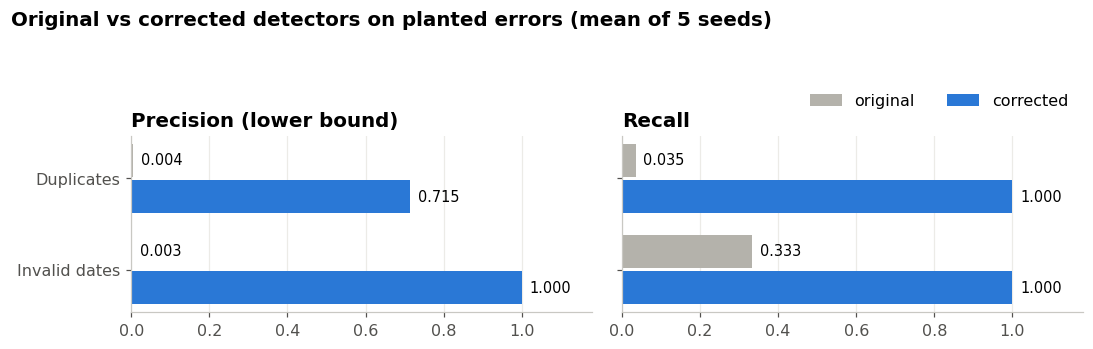

In [4]:
pairs = [('Invalid dates', 'original: placeholder dates', 'corrected: invalid dates'),
         ('Duplicates', 'original: same price, different dates', 'corrected: listing duplicates')]
fig, axes = plt.subplots(1, 2, figsize=(10, 3.2), sharey=True)
for ax, metric in zip(axes, ['precision', 'recall']):
    y = np.arange(len(pairs))
    for j, (who, color) in enumerate([(1, GRAY), (2, BLUE)]):
        vals = [m[m.detector == p[who]][metric].mean() for p in pairs]
        bars = ax.barh(y + (0.2 if j == 0 else -0.2), vals, height=0.36, color=color,
                       label='original' if j == 0 else 'corrected')
        for b, v in zip(bars, vals):
            ax.text(v + 0.02, b.get_y() + b.get_height() / 2, f'{v:.3f}', va='center', fontsize=9.5)
    ax.set_yticks(y, [p[0] for p in pairs]); ax.set_xlim(0, 1.18); ax.invert_yaxis()
    ax.set_title(metric.capitalize() + (' (lower bound)' if metric == 'precision' else ''))
    ax.grid(axis='y', visible=False)
axes[1].legend(loc='upper right', bbox_to_anchor=(1.0, 1.32), ncol=2, frameon=False)
fig.suptitle(f'Original vs corrected detectors on planted errors (mean of {SEEDS} seeds)',
             x=0.01, ha='left', fontweight='bold', fontsize=13)
plt.tight_layout(); plt.show()

**Reading the table**

- **Invalid dates.** The original detector flags ~738,000 records to catch a third of the planted errors (precision
  0.003): the missing-value bug from Part 1 dominates, and its list misses `1970-01-01`, `9999-12-31` and every typo year.
  The corrected detector finds every planted error. This family is the easiest by construction (see Limitations).
- **Duplicates.** The original detectors find **under 4%** of planted duplicates. They can't see an exact copy at all,
  since identical dates give a time span of 0 days, and the few hits are copies of a record that already belonged to a `for_sale` + `sold` pair
  (300 of 300 source records in seed 0). The corrected detector finds all of them; its lower-bound precision of 0.72 comes from the 4,815 records it
  also flags in the unmodified data (§4).
- **Price unit errors.** At the a-priori threshold of 3.5, the robust z-score catches 92% of planted errors. Its
  lower-bound precision is low because 4% of real listings have genuinely extreme prices per square foot, but 84% of
  its flags in corrupted data are either planted errors or records it already flags in the real data.

### Recall by error subtype

In [5]:
pivot = (sub.groupby(['family', 'subtype', 'detector'])['recall'].mean()
         .unstack('detector')[[d for d in ORDER if d in sub.detector.unique()]])
pivot.style.format('{:.3f}', na_rep='').background_gradient(cmap='Blues', vmin=0, vmax=1, axis=None)

The hardest case is the **×10 price error**: 21% are missed. A tenfold price lands inside the natural spread of some zip
codes (e.g. a luxury home in a mostly modest area), so it is not separable from a real price without more context.

## 3. Domain statistic vs. generic anomaly detection

For the price family I compare *rankings* rather than one threshold: average precision (area under the precision–recall
curve) and R-precision (the share of planted errors among the top-k scores, k = number planted).

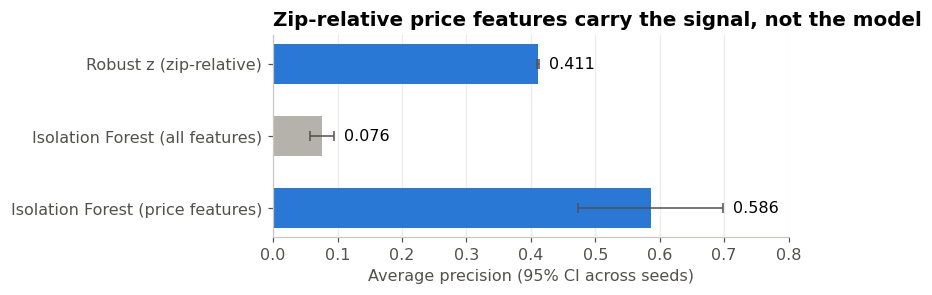

,detector,AP,AP ±,R-precision,R-precision ±,flags at default threshold
0,Robust z (zip-relative),0.411,0.002,0.548,0.003,91813.0
1,Isolation Forest (all features),0.076,0.019,0.120,0.051,329911.2
2,Isolation Forest (price features),0.586,0.113,0.583,0.034,342137.8


In [6]:
price = ['corrected: robust z (|z| > 3.5)', 'ML baseline: isolation forest',
         'ML baseline: isolation forest (price features)']
labels_short = ['Robust z (zip-relative)', 'Isolation Forest (all features)', 'Isolation Forest (price features)']
res = pd.DataFrame([{'detector': lab, 'AP': ci(m[m.detector == d].average_precision)[0],
                     'AP ±': ci(m[m.detector == d].average_precision)[1],
                     'R-precision': ci(m[m.detector == d].r_precision)[0],
                     'R-precision ±': ci(m[m.detector == d].r_precision)[1],
                     'flags at default threshold': m[m.detector == d].flagged.mean()}
                    for d, lab in zip(price, labels_short)])
assert res.AP.iloc[2] > 5 * res.AP.iloc[1]          # features matter more than the model
assert res['R-precision'].iloc[2] - res['R-precision'].iloc[0] < 0.1

fig, ax = plt.subplots(figsize=(7.5, 2.8))
y = np.arange(len(res))
ax.barh(y, res.AP, xerr=res['AP ±'], color=[BLUE, GRAY, BLUE], height=0.55,
        error_kw=dict(ecolor='#52514e', capsize=3, lw=1))
for i, r in res.iterrows():
    ax.text(r.AP + r['AP ±'] + 0.015, i, f'{r.AP:.3f}', va='center')
ax.set_yticks(y, res.detector); ax.invert_yaxis(); ax.set_xlim(0, 0.8)
ax.set_xlabel('Average precision (95% CI across seeds)')
ax.set_title('Zip-relative price features carry the signal, not the model')
ax.grid(axis='y', visible=False)
plt.tight_layout(); plt.show()
res.round(3)

Three results:

1. **Features matter more than the model.** The same Isolation Forest goes from AP 0.08 to 0.59 when it is limited
   to the four price features, two of which are *relative to the zip-code median*. The extra features (bedrooms,
   bathrooms, lot size) make it isolate unusual houses, and an unusual house is not a price error.
2. **With the right features, the two methods rank errors about equally well.** The forest has the higher average
   precision (0.59 vs 0.41), but its R-precision is close (0.58 vs 0.55) and it varies much more between seeds.
3. **Only the z-score gives a usable alert rule as it stands.** At its default threshold the forest flags about 15% of the
   dataset (340,000 records); the z-score's a-priori threshold flags 4% and comes with an explanation a reviewer can
   check ("price per sq ft is far above the zip-code median"). The forest would need a threshold calibrated on
   held-out labels before it could be used for alerts.

## 4. What the corrected detectors find in the real data

Flags on the *unmodified* dataset are not scored (there is no ground truth), but they are the reason to build the
detectors. Each group below is a candidate for review.

In [7]:
raw = load_raw()
bad_dates = raw[detectors.invalid_dates(raw)]
dup = raw[detectors.duplicates(raw)]
z = detectors.price_robust_z(raw, mad_floor_quantile=None)   # the detector as evaluated in §2
print(f'invalid dates      : {len(bad_dates)} records -> {bad_dates.prev_sold_date.tolist()}')
print(f'listing duplicates : {len(dup):,} records in {dup.groupby(detectors.LISTING_KEY).ngroups:,} groups')
print(f'price |z| > 3.5    : {(z > 3.5).sum():,} records ({(z > 3.5).mean():.1%}); price = 0: {(raw.price == 0).sum()}')
assert len(bad_dates) == 2 and len(dup) == 4_815

invalid dates      : 2 records -> ['1970-01-01', '3019-04-02']
listing duplicates : 4,815 records in 1,565 groups
price |z| > 3.5    : 88,410 records (4.0%); price = 0: 280


In [8]:
cols = detectors.COMPARE + ['price', 'prev_sold_date']
exact = dup.duplicated(subset=detectors.LISTING_KEY + cols, keep=False).sum()
filled = dup[cols].notna().sum(axis=1)
print(f'exact copies among flagged duplicates: {exact}')
print('status of flagged duplicates:', dup.status.value_counts().to_dict())
dup.sort_values(['street', 'brokered_by']).head(6)[['status', 'street', 'brokered_by'] + cols]

exact copies among flagged duplicates: 0
status of flagged duplicates: {'for_sale': 2817, 'ready_to_build': 1820, 'sold': 178}


,status,street,brokered_by,bed,bath,acre_lot,house_size,price,prev_sold_date
988768,for_sale,3200.0,83387.0,NaN,1.0,20.00,NaN,695000.0,2016-10-17
991467,for_sale,3200.0,83387.0,NaN,NaN,20.00,NaN,695000.0,<NA>
1061740,for_sale,3387.0,44373.0,3.0,2.0,133.82,1672.0,400000.0,<NA>
1061881,for_sale,3387.0,44373.0,NaN,NaN,133.82,NaN,400000.0,<NA>
1138530,for_sale,3520.0,42755.0,1.0,NaN,960.00,600.0,1995000.0,<NA>
1138904,for_sale,3520.0,42755.0,NaN,NaN,960.00,NaN,1995000.0,2020-03-04


In [9]:
zero = raw[raw.price == 0]
print('status of price = 0 listings:', zero.status.value_counts().to_dict())
raw.assign(z=z).sort_values('z', ascending=False).query('price > 0').head(5)[
    ['status', 'price', 'house_size', 'bed', 'bath', 'city', 'state', 'z']]

status of price = 0 listings: {'ready_to_build': 266, 'for_sale': 14}


,status,price,house_size,bed,bath,city,state,z
927592,for_sale,29000.0,896.0,2.0,1.0,Watts,Oklahoma,1894.449827
1046589,for_sale,2530776.0,NaN,NaN,NaN,Palo Pinto,Texas,1528.377360
988398,for_sale,650000.0,1404.0,3.0,1.0,Watts,Oklahoma,1394.438808
1045547,for_sale,1800000.0,NaN,NaN,NaN,Palo Pinto,Texas,1389.204528
927663,for_sale,175000.0,3003.0,4.0,2.0,Watts,Oklahoma,1167.500422


- **Dates:** two real errors, a sale in the year 3019 and a `1970-01-01` (the Unix epoch, a classic default).
- **Duplicates:** none of the 4,815 flagged records are exact copies. They are the same listing entered twice with one
  copy missing fields, the same pattern as the *one attribute blanked* subtype. About 1,800 are `ready_to_build`
  listings, which may be several floor plans offered at one development address rather than duplicates; that ambiguity
  is why precision is reported as a range.
- **Prices:** the top flags are `price = 0`, mostly on `ready_to_build` listings. Placeholder values do exist in this
  dataset, but in the **price** column, not the date column the original series searched.
- **A weakness in the z-score:** among positive prices, the top flags have z above 1,000 for ordinary homes (a
  $29,000 house in Watts, OK). In those zip codes about 30% of listings share one identical price, so the median
  absolute deviation is about 0.0005 on the log scale and any other price looks extreme. A floor on the MAD would fix
  this. It is left for the package step rather than tuned here, so the threshold in this experiment stays a-priori.

### Follow-up: a floor on the MAD (added after the results above)

The fix keeps every zip code's MAD at or above the **5th percentile of zip-level MADs** (about 0.10 on the log scale,
i.e. prices per sq ft within a zip code are assumed to vary by at least ~10%). The floor is computed from the data
itself, not from the planted labels, and the 3.5 threshold is unchanged. Both versions were scored in the same
5-seed experiment.

In [10]:
versions = {'without floor (§2)': 'corrected: robust z (|z| > 3.5)', 'with MAD floor': 'corrected v2: robust z + MAD floor'}
fix = pd.DataFrame({name: {'flags per seed': m[m.detector == d].flagged.mean(),
                           'recall': m[m.detector == d].recall.mean(),
                           'precision (upper)': m[m.detector == d].precision_upper.mean(),
                           'average precision': m[m.detector == d].average_precision.mean(),
                           'R-precision': m[m.detector == d].r_precision.mean()}
                    for name, d in versions.items()})
assert fix.loc['recall'].nunique() == 1 or abs(fix.loc['recall'].diff().iloc[-1]) < 0.002
assert fix.loc['average precision', 'with MAD floor'] > fix.loc['average precision', 'without floor (§2)']

z2 = detectors.price_robust_z(raw)
top = raw.assign(z=z2).query('price > 0').sort_values('z', ascending=False)
worst_without, worst_with = z.loc[raw.price > 0].max(), top.z.iloc[0]
assert worst_without > 10 * worst_with
print(f'largest z on a positive price: {worst_without:,.0f} without the floor, {worst_with:,.0f} with it')
fix.round(3)

largest z on a positive price: 1,894 without the floor, 80 with it


,without floor (§2),with MAD floor
flags per seed,91813.000,90400.400
recall,0.924,0.924
precision (upper),0.839,0.844
average precision,0.411,0.446
R-precision,0.548,0.580


The floor removes the absurd scores (the largest z on a positive price falls from about 1,900 to 80), flags about 1,400 fewer
records per seed, keeps recall the same, and improves the ranking: average precision 0.41 → 0.45, R-precision
0.55 → 0.58, now level with the price-feature Isolation Forest on R-precision. It is the default in the `reaudit`
package and its `audit` command.

## 5. Limitations

1. **The same person designed the errors and the detectors.** The date family especially is solved almost by
   construction: the corrected detector's rules (strict format, sentinel list, plausible range) were written knowing what
   would be planted. The duplicate and price families are less circular (the tolerance and the 3.5 threshold were fixed
   before the experiment, and the price detector still misses 21% of ×10 errors), but none of these results show how the
   detectors would do on error types I didn't imagine.
2. **Planted errors are cleaner than real ones.** A real duplicate may differ in several fields at once; a real price
   error may be a transposed digit rather than a power of ten.
3. **Precision depends on how many errors are planted.** With 4,000 price errors among 2.2M records, even a good
   detector's precision is bounded by the real extreme prices it also flags. The upper bound and the ranking metrics
   (AP, R-precision) are the better comparison.
4. **Thresholds are not tuned.** Both thresholds (z > 3.5, Isolation Forest's default) were fixed in advance. Tuning on
   these labels would inflate results unless done on held-out seeds.
5. **The z-score was unstable when a zip code's prices barely vary** (§4). A MAD floor, added after the experiment
   and chosen without the labels, fixes it.
6. **One snapshot of one dataset.**

## 6. Takeaways

- The original duplicate detectors found **under 4%** of real duplicates while flagging 116,000–134,000 valid records.
- A corrected, missing-value-tolerant duplicate detector recovered **all** planted duplicates, and found 4,815
  near-duplicate records in the real data.
- For price errors, comparing each listing with its zip code mattered more than the model: Isolation Forest's average
  precision rose from 0.08 to 0.59 with zip-relative price features, roughly matching a robust z-score (0.41) that is
  simpler to explain and has a usable threshold.
- Next, [Part 3](https://www.kaggle.com/code/mariamfathiamin/real-estate-audit-3-duplicate-leakage-in-ml) asks what these errors cost: how much do duplicate listings that land in both train and test inflate the
  measured accuracy of a price model?